# Operadores morfológicos

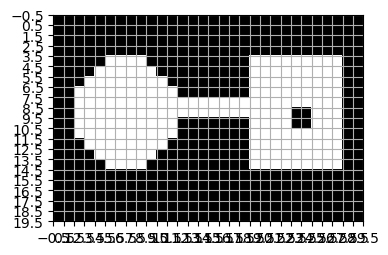

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def imshow_with_grid(img):
    """Plota imagem junto com uma grade para facilitar a visualização dos pixels"""
    plt.imshow(img, "gray")
    plt.xticks(np.arange(-0.5, img.shape[1]+0.5))
    plt.yticks(np.arange(-0.5, img.shape[0]+0.5))
    plt.grid()

img = plt.imread("../../dados/shape.tiff")
# A imagem está no intervalo [0, 255], o comando abaixo é utilizado
# para transformar a imagem para o tipo bool [False, True]
img = img > 0
imshow_with_grid(img)

## 1. Erosão

In [2]:
def erosion(img, struct_elem, ref_point):
    """Erosão de uma imagem binária img utilizando o elemento
       estruturante struct_elem. O ponto de referência do elemento estruturante
       é indicada pelo ponto ref_point."""

    num_rows, num_cols = img.shape
    
    # Armazena as coordenadas do elemento estruturante
    set_ee = get_se_coordinates(struct_elem, ref_point)
    
    # Alocação da imagem resultante da erosão
    img_res = np.zeros_like(img)
    for row in range(num_rows):
        for col in range(num_cols):
            is_contained = contained(img, set_ee, row, col)
            if is_contained:
                img_res[row, col] = 1
                
    return img_res

def get_se_coordinates(struct_elem, ref_point):
    """Retorna as coordenadas do elemento estruturante struct_elem
       em relação ao ponto de referência ref_point"""
    set_ee = []
    num_rows_ee, num_cols_ee = struct_elem.shape
    for row in range(num_rows_ee):
        for col in range(num_cols_ee):
            if struct_elem[row, col]==1:
                set_ee.append((row-ref_point[0], col-ref_point[1]))

    return set_ee

def contained(img, set_ee, row, col):
    """Verifica se os pontos contidos no conjunto 
       set_ee, transladados de uma quantia (row, col), mapeiam 
       todos para um pixel branco na imagem img"""

    for point in set_ee:
        # Translada o ponto
        trans_point = (row + point[0], col + point[1])
        # Se o ponto estiver fora da imagem, retorna Falso
        if trans_point[0]<0 or trans_point[0]>=img.shape[0] or \
           trans_point[1]<0 or trans_point[1]>=img.shape[1]:
            return False
        
        if img[trans_point]==0:
                return False
    return True

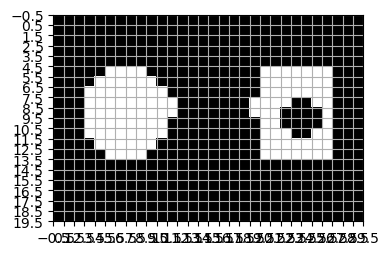

In [3]:
# Elemento estruturante
elem_est = np.array([[0, 1, 0],
                     [1, 1, 1],
                     [0, 1, 0]])

img_res = erosion(img, elem_est, ref_point=(1, 1))
imshow_with_grid(img_res)

## 2. Dilatação

In [4]:
def dilation(img, elem_est, ref_point):
    """Dilatação de uma imagem binária img utilizando o elemento
       estruturante elem_est. O ponto de referência do elemento estruturante
       é indicada pelo ponto ref_point."""

    num_rows, num_cols = img.shape

    set_ee = get_se_coordinates(elem_est, ref_point)
    # Para a dilatação, é necessário inverter o conjunto de pontos do elemento estruturante
    # para seguir fielmente a definição de dilatação
    set_ee = [(-point[0], -point[1]) for point in set_ee]
    
    img_res = np.zeros_like(img)
    for row in range(num_rows):
        for col in range(num_cols):
            has_intersect = intersects(img, set_ee, row, col)
            if has_intersect:
                img_res[row, col] = 1
                
    return img_res 

def intersects(img, set_ee, row, col):
    """Verifica se algum ponto do conjunto set_ee, transladado 
       de uma quantia (row, col), mapeia para um pixel branco na imagem img"""

    for point in set_ee:
        # Translada o ponto
        trans_point = (row + point[0], col + point[1])
        # Verifica ponto somente se ele estiver dentro da imagem
        if trans_point[0]>=0 and trans_point[0]<img.shape[0] and \
           trans_point[1]>=0 and trans_point[1]<img.shape[1]:
        
            if img[trans_point]==1:
                return True
    return False

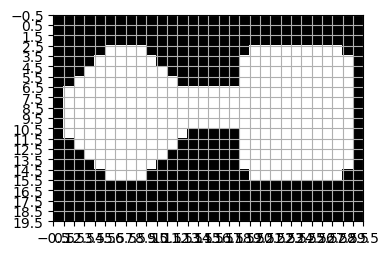

In [5]:
elem_est = np.array([[0, 1, 0],
                     [1, 1, 1],
                     [0, 1, 0]])

img_res = dilation(img, elem_est, ref_point=(1, 1))
imshow_with_grid(img_res)

## 3. Abertura e fechamento

In [6]:
def opening(img, elem_est, origin):
    img_eroded = erosion(img, elem_est, origin)
    img_opened = dilation(img_eroded, elem_est, origin)
    
    return img_opened

def closing(img, elem_est, origin):
    img_dilated = dilation(img, elem_est, origin)
    img_closed = erosion(img_dilated, elem_est, origin)
    
    return img_closed

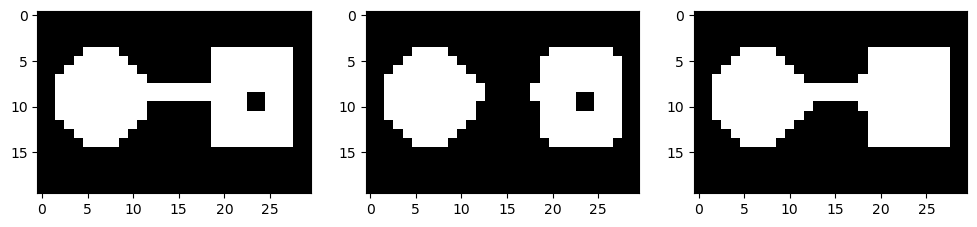

In [7]:
img_opened = opening(img, elem_est, (1,1))
img_closed = closing(img, elem_est, (1,1))

plt.figure(figsize=[12, 5])
plt.subplot(1, 3, 1)
plt.imshow(img, "gray")
plt.subplot(1, 3, 2)
plt.imshow(img_opened, "gray")
plt.subplot(1, 3, 3)
plt.imshow(img_closed, "gray")